# ROGII — Post-PS EDA (the scored region only)

**Why this notebook exists.** Notebooks 01–02 computed statistics over *whole wells*. The pre-PS descent
section (~750 ft of TVT and Z moving 1:1) numerically swamped the post-PS lateral (~25 ft of TVT motion) —
the only region submissions are scored on. Geometry baselines built on those whole-well statistics failed
badly (B2 RMSE 107 vs the flat baseline's 15.9), and a code review confirmed the implementation was correct:
the statistics were measured in the wrong regime. Here every measurement uses **post-PS rows only**, where
training wells still carry the true `TVT`.

**This notebook supersedes the conclusions of `02-eda-geometry.ipynb`.** Five questions:
1. What do the geometry statistics look like when measured only where we predict?
2. How does the target (`TVT`) actually behave there?
3. What is the structure of the deviation `TVT − TVT_PS` (the thing a model must predict)?
4. How much usable `GR` signal exists in the scored region?
5. Where does the flat baseline (B1, RMSE 15.91) fail?

*Reading guide: red line on histograms = median (labelled); key-metrics tables state every number with a
plain meaning. True `TVT` is used for analysis/scoring only, never as a predictor.*

## 1. Setup

In [1]:
%matplotlib inline
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.labelsize": 11,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "axes.edgecolor": "#888",
})
BAR, MED, ID = "#4C78A8", "#E45756", "#54A24B"

def show_metrics(title, rows):
    df = pd.DataFrame(rows, columns=["Measurement", "Value", "What it means"])
    sty = (df.style.hide(axis="index").set_caption(title)
           .set_properties(**{"text-align": "left", "font-size": "12px", "padding": "4px 12px"})
           .set_table_styles([
               {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold"),
                                                  ("text-align", "left"), ("padding", "6px 0")]},
               {"selector": "th", "props": [("text-align", "left"), ("background", "#eef1f6"),
                                            ("padding", "4px 12px")]}]))
    display(sty)

def hist_med(ax, data, title, xlabel, fmt=lambda v: f"{v:.2f}", bins=30, xlim=None):
    d = pd.Series(data).dropna()
    ax.hist(d, bins=bins, color=BAR, edgecolor="white", linewidth=0.3)
    med = d.median(); ax.axvline(med, color=MED, lw=2)
    ax.text(0.04, 0.95, f"median {fmt(med)}", transform=ax.transAxes, ha="left", va="top",
            fontsize=10, bbox=dict(boxstyle="round", fc="white", ec=MED, alpha=0.9))
    ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel("wells")
    if xlim: ax.set_xlim(*xlim)

def find_root():
    for c in [Path.cwd(), *Path.cwd().parents]:
        if (c / "data" / "raw" / "train").is_dir():
            return c.resolve()
    raise FileNotFoundError("competition root not found")

ROOT = find_root()
sys.path.insert(0, str(ROOT / "src"))
from well_io import load_lateral, split_ps, true_tvt
from baselines import b1_carry_forward
from eval import rmse

TRAIN = ROOT / "data" / "raw" / "train"
PROCESSED = ROOT / "data" / "processed"

def corr(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    return np.corrcoef(a[m], b[m])[0, 1] if m.sum() > 3 else np.nan

def ols_slope(x, y):
    # slope of y ~ x, NaN-safe; NaN when x is (near-)constant
    x, y = np.asarray(x, float), np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 3 or np.ptp(x[m]) < 1e-9: return np.nan
    return np.polyfit(x[m], y[m], 1)[0]

def spear(a, b):
    # Spearman = Pearson on ranks (avoids the scipy dependency)
    return corr(pd.Series(a).rank(), pd.Series(b).rank())

wells = sorted(TRAIN.glob("*__horizontal_well.csv"))
print("train wells:", len(wells))

train wells: 773


## 2. One streaming pass — every per-well post-PS statistic

One read per well. Per-well summaries cached to `data/processed/post-ps-summary.parquet`; pooled row-level
structures (deviation-vs-horizon, sampled deviation curves) kept in memory for the sections below.

In [2]:
PRE_WIN, DEPART_FT, RUN_FT, HBIN = 200, 5.0, 200, 250

rng = np.random.default_rng(0)
spagh_ids = set(rng.choice(len(wells), 40, replace=False))

rows, hz_off, hz_val, spagh = [], [], [], []
for k, p in enumerate(wells):
    df = load_lateral(p)
    known, predict, ps = split_ps(df)
    tvt_all = true_tvt(df).to_numpy(float)
    t = tvt_all[ps:]                                   # true target, scored region
    z = predict["Z"].to_numpy(float)
    gr = predict["GR"].to_numpy(float)
    n = len(t)
    if n < 30 or len(known) < PRE_WIN: continue
    anchor = float(known["TVT_input"].iloc[-1])        # B1's prediction, the PS anchor

    # -- corrected geometry statistics (post-PS only) --
    negz = -z
    c_tz, b_post = corr(t, negz), ols_slope(negz, t)
    dt, dnz = np.diff(t), np.diff(negz)
    c_dd, b_inc = corr(dt, dnz), ols_slope(dnz, dt)
    m = np.isfinite(dt) & np.isfinite(dnz)
    resid_var = np.var(dt[m] - dnz[m]) / np.var(dt[m]) if m.sum() > 3 else np.nan
    kt, kz = known["TVT_input"].to_numpy(float)[-PRE_WIN:], -known["Z"].to_numpy(float)[-PRE_WIN:]
    b_pre = ols_slope(kz, kt)                          # slope on the drilled lateral tail
    d = t + z

    # -- target behavior --
    dev = t - anchor                                   # deviation from the PS anchor = B1's error
    trend = np.polyval(np.polyfit(np.arange(n), t, 1), np.arange(n))
    drift, wiggle = abs(t[-1] - anchor), float(np.std(t - trend))

    # -- deviation structure --
    ac1 = corr(dt[:-1], dt[1:])
    ac50 = corr(dt[:-50], dt[50:]) if n > 60 else np.nan
    s = np.sign(dt); s = s[s != 0]
    run_mean = np.mean(np.diff(np.flatnonzero(np.r_[True, s[1:] != s[:-1], True]))) if len(s) else np.nan
    dep = np.flatnonzero(np.abs(dev) > DEPART_FT)
    crossed = bool(len(dep)) and bool(np.nanmin(dev[dep[0]:]) < 0 < np.nanmax(dev[dep[0]:]))

    # -- GR usability --
    fin = np.isfinite(gr)
    cov = fin.mean()
    runs = np.diff(np.flatnonzero(np.r_[True, fin[1:] != fin[:-1], True]))
    lens, vals = runs, fin[np.r_[0, np.cumsum(runs)[:-1]]]
    good, gaps = lens[vals], lens[~vals]
    longest = int(good.max()) if len(good) else 0
    n_long = int((good >= RUN_FT).sum())
    gap_med = float(np.median(gaps)) if len(gaps) else 0.0
    fin_b = pd.Series(np.where(fin, 1.0, np.nan)).ffill(limit=5).notna().to_numpy()  # bridge gaps <=5 ft
    runs_b = np.diff(np.flatnonzero(np.r_[True, fin_b[1:] != fin_b[:-1], True]))
    vals_b = fin_b[np.r_[0, np.cumsum(runs_b)[:-1]]]
    good_b = runs_b[vals_b]
    longest_b = int(good_b.max()) if len(good_b) else 0
    nlong_b = int((good_b >= RUN_FT).sum())

    # -- B1 anatomy --
    b1 = rmse(b1_carry_forward(known, predict), t)

    rows.append(dict(well_id=p.name.split("__")[0], n_post=n, anchor=anchor,
        c_tz=c_tz, b_post=b_post, c_dd=c_dd, b_inc=b_inc, resid_var=resid_var, b_pre=b_pre,
        rng_tvt=np.ptp(t), rng_negz=np.ptp(negz), rng_d=np.ptp(d),
        std_tvt=t.std(), std_negz=negz.std(), std_d=d.std(),
        drift=drift, wiggle=wiggle, ac1=ac1, ac50=ac50, run_mean=run_mean, crossed=crossed,
        gr_cov=cov, gr_longest=longest, gr_nlong=n_long, gr_gap_med=gap_med,
        gr_longest_b=longest_b, gr_nlong_b=nlong_b, b1_rmse=b1))

    off = np.arange(n) // HBIN * HBIN                  # ft-since-PS, binned (1 row = 1 ft)
    hz_off.append(off); hz_val.append(np.abs(dev))
    if k in spagh_ids: spagh.append((p.name.split("__")[0], dev))

S = pd.DataFrame(rows)
PROCESSED.mkdir(parents=True, exist_ok=True)
S.to_parquet(PROCESSED / "post-ps-summary.parquet", index=False)
hz = pd.DataFrame({"off": np.concatenate(hz_off), "val": np.concatenate(hz_val)})
print(f"wells summarized: {len(S)}  |  pooled scored rows: {len(hz):,}")
print(f"B1 pooled RMSE (harness cross-check, expect 15.91): "
      f"{np.sqrt((S.b1_rmse**2 * S.n_post).sum() / S.n_post.sum()):.2f}")

wells summarized: 773  |  pooled scored rows: 3,783,989
B1 pooled RMSE (harness cross-check, expect 15.91): 15.91


## 3. Corrected geometry statistics — old (whole-well) vs new (post-PS only)

The table below is the record-fixer: each row pairs the number notebook 02 reported over whole wells with the
same measurement on scored rows only. The histograms show what the geometry baselines actually assumed vs
what holds: B2 assumed `TVT` rides `−Z` at slope **1**; the right panel shows the slope seen on the drilled
lateral does not carry over to the predicted section.

Measurement,Value,What it means
"corr(TVT, −Z)",0.92 → 0.09,whole-well lockstep was the descent section; in the lateral the level relationship is weak
slope of TVT vs −Z,(assumed 1.00) → 0.01,"per ft the bit moves down in space, TVT moves this much — B2 hard-coded 1.00"
"corr(ΔTVT, −ΔZ), 1-ft",0.99 → 0.67,step-by-step lockstep also collapses once the descent section is excluded
ΔTVT variance left after −ΔZ,2% → 64%,removing −ΔZ no longer explains the target's motion
range(−Z) / range(TVT),6.0×,"post-PS, physical depth swings this many times more than depth-in-rock"
range(D) vs range(TVT),0.31 → 6.0×,the 'small smooth residual' D is actually the larger quantity in the scored region
"slope transfer, drilled → predicted",corr = 0.00,the TVT~−Z slope estimated on the drilled lateral does not predict the slope after PS


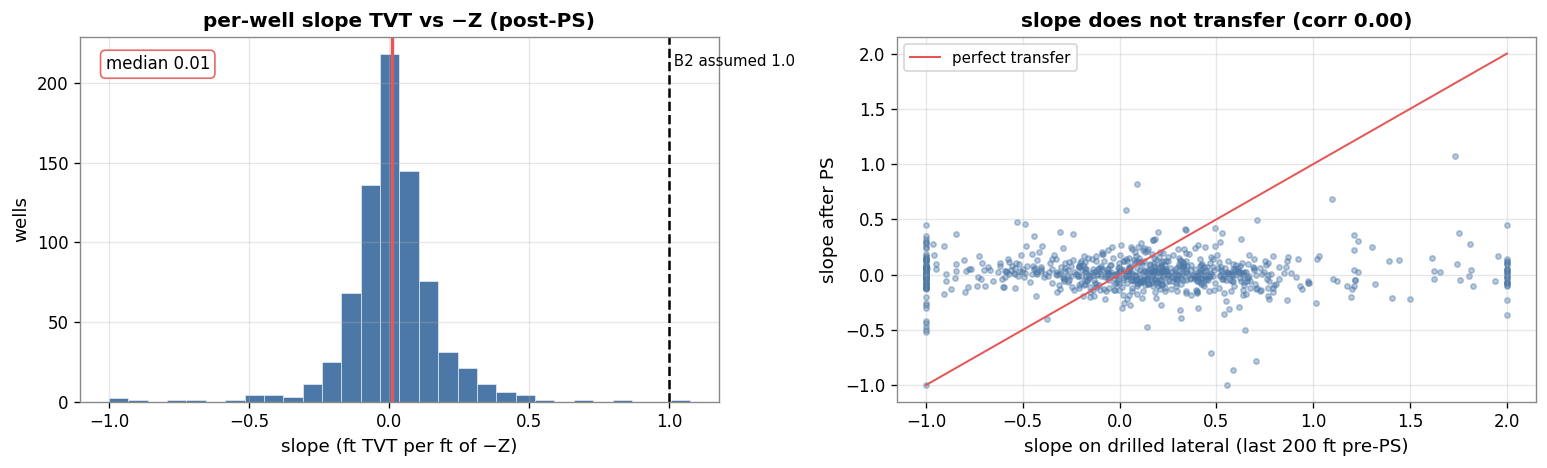

In [3]:
show_metrics("Geometry, re-measured where it matters (medians across 773 wells)", [
    ("corr(TVT, −Z)",            f"0.92 → {S.c_tz.median():.2f}",
     "whole-well lockstep was the descent section; in the lateral the level relationship is weak"),
    ("slope of TVT vs −Z",       f"(assumed 1.00) → {S.b_post.median():.2f}",
     "per ft the bit moves down in space, TVT moves this much — B2 hard-coded 1.00"),
    ("corr(ΔTVT, −ΔZ), 1-ft",    f"0.99 → {S.c_dd.median():.2f}",
     "step-by-step lockstep also collapses once the descent section is excluded"),
    ("ΔTVT variance left after −ΔZ", f"2% → {S.resid_var.median()*100:.0f}%",
     "removing −ΔZ no longer explains the target's motion"),
    ("range(−Z) / range(TVT)",   f"{(S.rng_negz/S.rng_tvt).median():.1f}×",
     "post-PS, physical depth swings this many times more than depth-in-rock"),
    ("range(D) vs range(TVT)",   f"0.31 → {(S.rng_d/S.rng_tvt).median():.1f}×",
     "the 'small smooth residual' D is actually the larger quantity in the scored region"),
    ("slope transfer, drilled → predicted", f"corr = {corr(S.b_pre, S.b_post):.2f}",
     "the TVT~−Z slope estimated on the drilled lateral does not predict the slope after PS"),
])

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
hist_med(ax[0], S.b_post.clip(-1, 2), "per-well slope TVT vs −Z (post-PS)", "slope (ft TVT per ft of −Z)")
ax[0].axvline(1.0, color="black", lw=1.5, ls="--")
ax[0].text(1.0, ax[0].get_ylim()[1]*0.92, " B2 assumed 1.0", fontsize=9)
ax[1].scatter(S.b_pre.clip(-1, 2), S.b_post.clip(-1, 2), s=10, alpha=0.4, color=BAR)
ax[1].plot([-1, 2], [-1, 2], color=MED, lw=1.2, label="perfect transfer")
ax[1].set_xlabel("slope on drilled lateral (last 200 ft pre-PS)"); ax[1].set_ylabel("slope after PS")
ax[1].set_title(f"slope does not transfer (corr {corr(S.b_pre, S.b_post):.2f})"); ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

## 4. The actual target — how `TVT` behaves where we predict

`TVT`'s total excursion per well, split into **drift** (where it ends up relative to the PS anchor — what a
flat prediction gets wrong at the far end) and **wiggle** (motion around its own trend). The right panel is
the key chart: how far the truth pulls away from the PS anchor as the horizon grows — i.e. B1's error as a
function of distance drilled past PS.

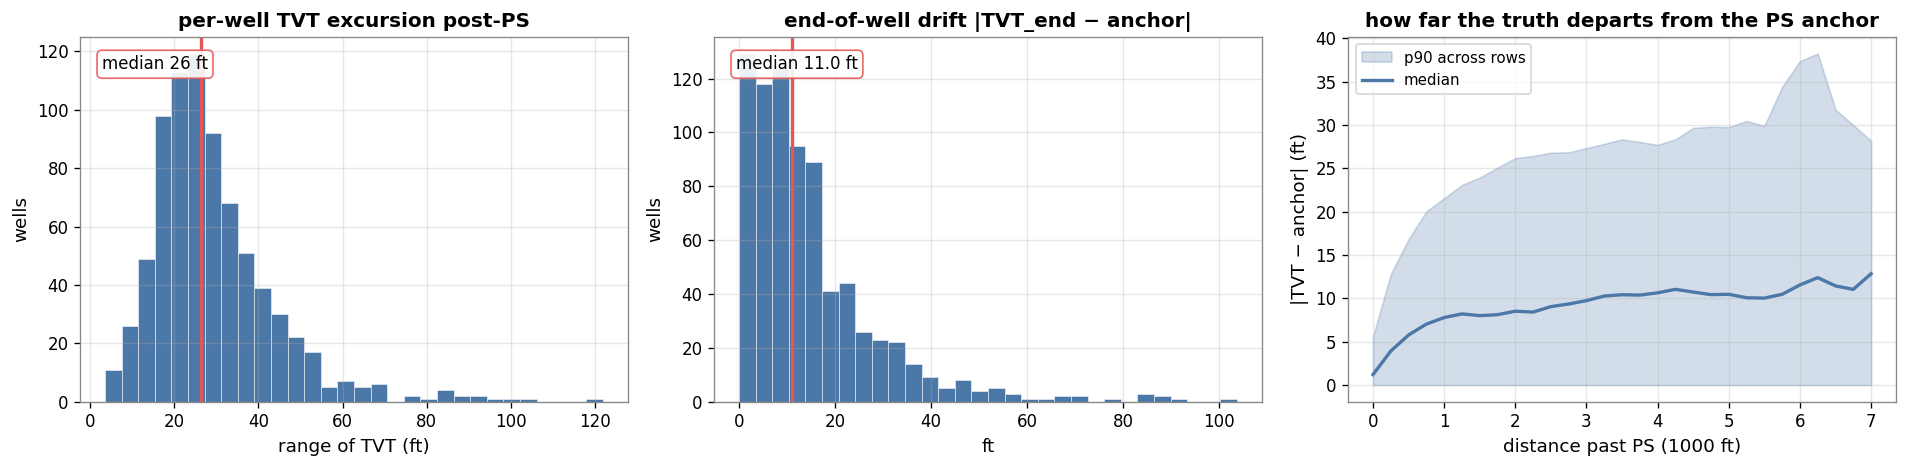

Measurement,Value,What it means
TVT excursion per well,26 ft (p90 47),total vertical range the target covers over thousands of ft of drilling — small by design (steering)
end-of-well drift,11.0 ft (p90 32.0),where the well ends relative to the PS anchor — the part of B1's error that grows with horizon
wiggle around trend,5.4 ft,short-scale motion a smooth drift model would still miss
"departure at 5,000 ft past PS","median 10.5 ft, p90 29.7 ft",typical and bad-case anchor error deep into the predicted section


In [4]:
g = hz.groupby("off")["val"]
ghi = g.agg(median="median", p90=lambda v: v.quantile(.9), n="size").reset_index()
ghi = ghi[ghi.n >= 30 * 250]

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
hist_med(ax[0], S.rng_tvt, "per-well TVT excursion post-PS", "range of TVT (ft)", lambda v: f"{v:.0f} ft")
hist_med(ax[1], S.drift, "end-of-well drift |TVT_end − anchor|", "ft", lambda v: f"{v:.1f} ft")
ax[2].fill_between(ghi.off/1000, 0, ghi.p90, color=BAR, alpha=0.25, label="p90 across rows")
ax[2].plot(ghi.off/1000, ghi["median"], color=BAR, lw=2, label="median")
ax[2].set_xlabel("distance past PS (1000 ft)"); ax[2].set_ylabel("|TVT − anchor| (ft)")
ax[2].set_title("how far the truth departs from the PS anchor"); ax[2].legend(fontsize=9)
plt.tight_layout(); plt.show()

show_metrics("Target behavior (medians)", [
    ("TVT excursion per well",   f"{S.rng_tvt.median():.0f} ft (p90 {S.rng_tvt.quantile(.9):.0f})",
     "total vertical range the target covers over thousands of ft of drilling — small by design (steering)"),
    ("end-of-well drift",        f"{S.drift.median():.1f} ft (p90 {S.drift.quantile(.9):.1f})",
     "where the well ends relative to the PS anchor — the part of B1's error that grows with horizon"),
    ("wiggle around trend",      f"{S.wiggle.median():.1f} ft",
     "short-scale motion a smooth drift model would still miss"),
    ("departure at 5,000 ft past PS", f"median {ghi.set_index('off')['median'].get(5000, np.nan):.1f} ft, "
     f"p90 {ghi.set_index('off')['p90'].get(5000, np.nan):.1f} ft",
     "typical and bad-case anchor error deep into the predicted section"),
])

## 5. Structure of the deviation `TVT − anchor` — what a model must actually predict

Sampled deviation curves (grey) with the pooled median magnitude (red). The metrics ask: is the deviation
smooth and persistent (predictable drift), or noisy and mean-reverting (hard)? This is the empirical prior an
alignment model's continuity constraint should encode.

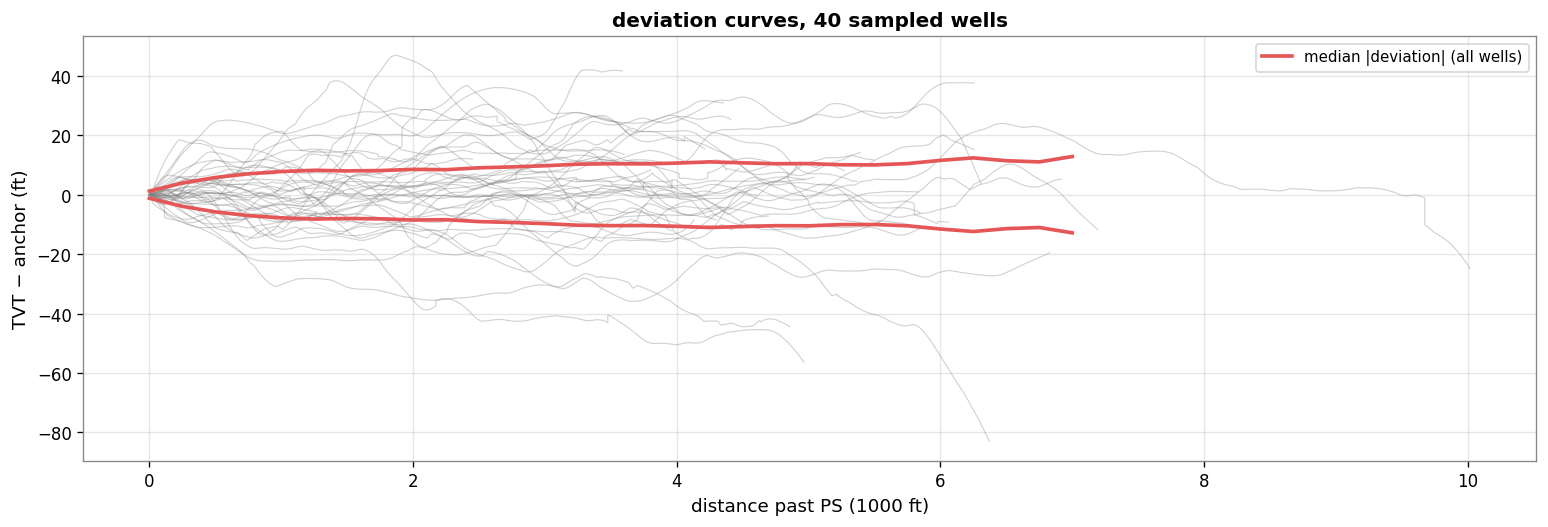

Measurement,Value,What it means
step-to-step autocorr of ΔTVT (lag 1 ft),0.91,"successive 1-ft changes are correlated → the path is smooth, not white noise"
autocorr at lag 50 ft,0.67,direction persists over tens of ft → locally predictable drift
mean same-direction run,170 ft,typical stretch the target keeps rising or falling before turning
wells that cross back through the anchor,62%,"after departing >5 ft, does the truth ever return past the anchor? (mean-reversion check)"


In [5]:
fig, ax = plt.subplots(figsize=(13, 4.5))
for wid_, dev in spagh:
    ax.plot(np.arange(len(dev))/1000, dev, color="grey", alpha=0.35, lw=0.7)
ax.plot(ghi.off/1000, ghi["median"], color=MED, lw=2.2, label="median |deviation| (all wells)")
ax.plot(ghi.off/1000, -ghi["median"], color=MED, lw=2.2)
ax.set_xlabel("distance past PS (1000 ft)"); ax.set_ylabel("TVT − anchor (ft)")
ax.set_title("deviation curves, 40 sampled wells"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

show_metrics("Deviation structure (medians across wells)", [
    ("step-to-step autocorr of ΔTVT (lag 1 ft)", f"{S.ac1.median():.2f}",
     "successive 1-ft changes are correlated → the path is smooth, not white noise"),
    ("autocorr at lag 50 ft",     f"{S.ac50.median():.2f}",
     "direction persists over tens of ft → locally predictable drift"),
    ("mean same-direction run",   f"{S.run_mean.median():.0f} ft",
     "typical stretch the target keeps rising or falling before turning"),
    ("wells that cross back through the anchor", f"{S.crossed.mean()*100:.0f}%",
     "after departing >5 ft, does the truth ever return past the anchor? (mean-reversion check)"),
])

## 6. `GR` usability in the scored region

Alignment is the only route to beating B1, and it needs contiguous `GR` to match against the typewell. Per
well: post-PS coverage, the longest unbroken run, and whether wells where B1 fails worst still have signal to
align (right panel).

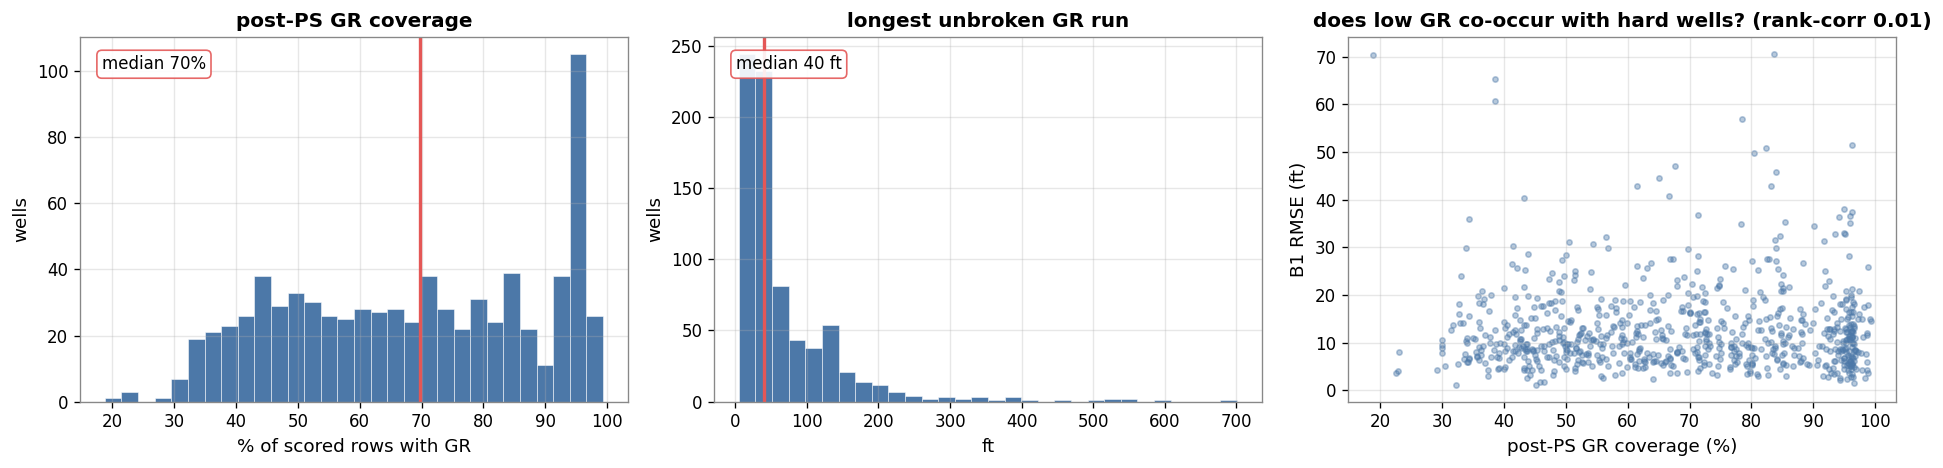

Measurement,Value,What it means
post-PS coverage,70% (p10 41%),fraction of scored rows where the rock sensor reads at all
longest unbroken run,40 ft (p10 17),the biggest single window available for sequence matching
runs ≥ 200 ft per well,0,matchable windows per well — alignment needs at least a few
median gap length,1 ft,typical hole the aligner must bridge between windows
longest run after bridging gaps ≤5 ft,1164 ft (runs ≥200 ft: 3/well),the gaps are pinholes: filling holes ≤5 ft turns short raw runs into long matchable windows
coverage vs B1 difficulty,rank-corr 0.01,negative = the hardest wells also tend to have less signal to align with


In [6]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
hist_med(ax[0], S.gr_cov*100, "post-PS GR coverage", "% of scored rows with GR", lambda v: f"{v:.0f}%")
hist_med(ax[1], S.gr_longest, "longest unbroken GR run", "ft", lambda v: f"{v:.0f} ft")
ax[2].scatter(S.gr_cov*100, S.b1_rmse, s=10, alpha=0.4, color=BAR)
ax[2].set_xlabel("post-PS GR coverage (%)"); ax[2].set_ylabel("B1 RMSE (ft)")
ax[2].set_title(f"does low GR co-occur with hard wells? (rank-corr "
                f"{spear(S.gr_cov, S.b1_rmse):.2f})")
plt.tight_layout(); plt.show()

show_metrics("GR signal availability (medians)", [
    ("post-PS coverage",      f"{S.gr_cov.median()*100:.0f}% (p10 {S.gr_cov.quantile(.1)*100:.0f}%)",
     "fraction of scored rows where the rock sensor reads at all"),
    ("longest unbroken run",  f"{S.gr_longest.median():.0f} ft (p10 {S.gr_longest.quantile(.1):.0f})",
     "the biggest single window available for sequence matching"),
    ("runs ≥ 200 ft per well", f"{S.gr_nlong.median():.0f}",
     "matchable windows per well — alignment needs at least a few"),
    ("median gap length",     f"{S.gr_gap_med.median():.0f} ft",
     "typical hole the aligner must bridge between windows"),
    ("longest run after bridging gaps ≤5 ft", f"{S.gr_longest_b.median():.0f} ft "
     f"(runs ≥200 ft: {S.gr_nlong_b.median():.0f}/well)",
     "the gaps are pinholes: filling holes ≤5 ft turns short raw runs into long matchable windows"),
    ("coverage vs B1 difficulty", f"rank-corr {spear(S.gr_cov, S.b1_rmse):.2f}",
     "negative = the hardest wells also tend to have less signal to align with"),
])

## 7. Where B1 (the 15.91 floor) actually fails

Pooled RMSE hides the shape of the error. Is 15.91 a few catastrophic wells or uniform mediocrity? And what
distinguishes the bad wells — length, drift, missing GR?

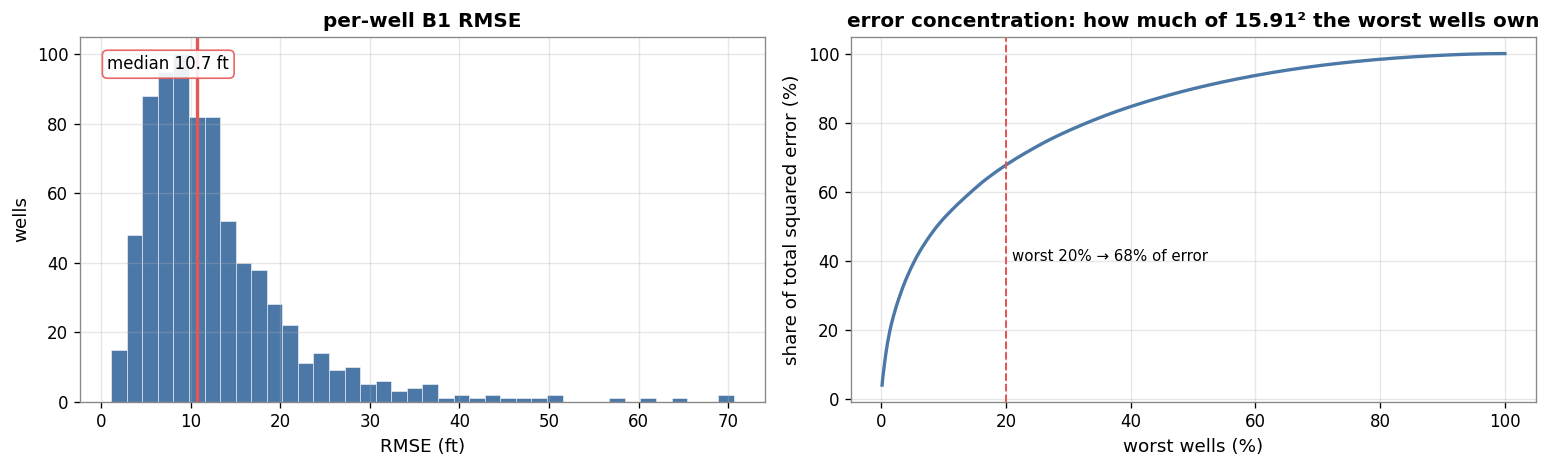

well,B1 RMSE,scored rows,TVT range,end drift,GR cov
1b1eba53,70.6,4655,99,71,84%
86454a6f,70.3,7964,97,79,19%
a959858c,65.4,4404,91,90,39%
2fd68f7b,60.7,4730,76,64,39%
5f4d2a52,56.9,5225,94,52,78%
f88ddb26,51.4,4990,79,41,96%
ba48188d,50.9,4166,105,104,82%
389ae58f,49.8,6463,68,52,80%
f6d009f4,47.0,6715,84,84,68%
43e16325,45.8,3720,84,84,84%


Measurement,Value,What it means
scored-section length,+0.15,longer horizon → more room to drift away from the anchor
end-of-well drift,+0.59,near-definitional: B1's error IS the drift — sanity check
TVT excursion,+0.78,wells where steering held less tightly are harder
GR coverage,+0.01,"if negative, alignment has least signal where it is most needed"
slope TVT~−Z,+0.11,whether residual geometry coupling marks hard wells


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
hist_med(ax[0], S.b1_rmse, "per-well B1 RMSE", "RMSE (ft)", lambda v: f"{v:.1f} ft", bins=40)
sse = (S.b1_rmse**2 * S.n_post).sort_values(ascending=False)
share = sse.cumsum() / sse.sum()
ax[1].plot(np.arange(1, len(share)+1)/len(share)*100, share*100, color=BAR, lw=2)
ax[1].set_xlabel("worst wells (%)"); ax[1].set_ylabel("share of total squared error (%)")
ax[1].set_title("error concentration: how much of 15.91² the worst wells own")
k20 = share.iloc[int(len(share)*0.2)-1]*100
ax[1].axvline(20, color=MED, lw=1.2, ls="--"); ax[1].text(21, 40, f"worst 20% → {k20:.0f}% of error", fontsize=9)
plt.tight_layout(); plt.show()

worst = S.nlargest(20, "b1_rmse")[["well_id", "b1_rmse", "n_post", "rng_tvt", "drift", "gr_cov"]]
worst.columns = ["well", "B1 RMSE", "scored rows", "TVT range", "end drift", "GR cov"]
display(worst.style.hide(axis="index").format({"B1 RMSE": "{:.1f}", "TVT range": "{:.0f}",
        "end drift": "{:.0f}", "GR cov": "{:.0%}"}).set_caption("20 worst wells under B1"))

rc = {c: spear(S.b1_rmse, S[c]) for c in ["n_post", "drift", "rng_tvt", "gr_cov", "b_post"]}
show_metrics("What correlates with B1 failing (Spearman rank-corr vs per-well B1 RMSE)", [
    ("scored-section length", f"{rc['n_post']:+.2f}", "longer horizon → more room to drift away from the anchor"),
    ("end-of-well drift",     f"{rc['drift']:+.2f}", "near-definitional: B1's error IS the drift — sanity check"),
    ("TVT excursion",         f"{rc['rng_tvt']:+.2f}", "wells where steering held less tightly are harder"),
    ("GR coverage",           f"{rc['gr_cov']:+.2f}", "if negative, alignment has least signal where it is most needed"),
    ("slope TVT~−Z",          f"{rc['b_post']:+.2f}", "whether residual geometry coupling marks hard wells"),
])

## 8. Findings

**Supersedes the conclusions of `02-eda-geometry.ipynb`** (whole-well statistics, contaminated by the
pre-PS descent section). Baseline record: `notebooks/modeling/01-baselines.ipynb`.

### 1. The corrected record — whole-well vs scored-region-only

| Measurement | whole-well (nb 02) | post-PS only | verdict |
|---|---|---|---|
| corr(TVT, −Z) | 0.92 | **0.09** | level relationship gone |
| slope TVT vs −Z | assumed 1.0 | **0.01** | B2's core assumption false |
| corr(ΔTVT, −ΔZ), 1 ft | 0.99 | **0.67** | partial step coupling remains, but… |
| ΔTVT variance left after −ΔZ | 2% | **64%** | …removing −ΔZ explains little |
| range(−Z) / range(TVT) | ~1 | **6.0×** | Z is the wild quantity, TVT the stable one |
| slope transfer, drilled → predicted | 0.77 (for D) | **0.00** | nothing about the TVT~Z coupling extrapolates |

Physical story: post-PS the driller steers to hold the bit inside the layer, so **TVT is held nearly
constant by intent** (median excursion 26 ft over thousands of ft) while **Z absorbs the layers' structural
relief** (~6× larger swings). Geometry offers no shortcut; the whole-well lockstep was the descent section.

### 2. The target's true shape
- Median per-well TVT excursion **26 ft** (p90 47); end-of-well drift from the PS anchor **11 ft** (p90 32).
- Departure from the anchor grows with horizon: **~10.5 ft median / ~30 ft p90 at 5,000 ft past PS** —
  this curve *is* B1's error anatomy: cheap near PS, expensive deep in the lateral.

### 3. Prior for the alignment model (what `TVT − anchor` looks like)
- **Smooth**: lag-1 autocorr of ΔTVT = 0.91; direction persists ~**170 ft** per run.
- **Not a fixed trend**: 62% of wells cross back through the anchor after departing >5 ft, and the drilled
  section's slope says nothing about the future (transfer corr 0.00).
- → the deviation is a smooth, bounded wander (±~50 ft worst case), locally persistent but globally
  direction-less. A model should enforce **continuity + small step size**, and get the *level* from GR
  evidence — not extrapolate a trend.

### 4. GR signal: pinholes, not chasms
- Median post-PS coverage **70%** (p10 41%), but raw unbroken runs are short (median longest ≈ 40 ft)
  because the gaps are tiny — **median gap 1 ft**.
- Bridging gaps ≤5 ft turns these into long matchable windows (see §6 table) → alignment is viable on
  most wells after trivial gap-filling; missingness is not the binding constraint.
- GR coverage is **uncorrelated with B1 difficulty** (rank-corr 0.01): the hard wells still have signal.

### 5. Where the 15.91 lives
- Per-well B1 RMSE: median ~10.7, p90 ~23, worst 70.6 — a heavy tail, not uniform mediocrity.
- What marks a hard well: **TVT excursion (rank-corr +0.78)** and end drift (+0.59) — i.e. wells where
  steering held less tightly. Length (+0.15), GR coverage (+0.01) and residual geometry (+0.11) barely matter.
- → the gap from 15.9 toward the leaders' ~8–9 is concentrated in **high-excursion wells deep past PS**;
  that is exactly where an aligner that tracks the rock signal should pay off first.